# Идеальная асферическая линза

Задача: найти профиль осесимметричной линзы из материала с показателем преломления $n$, образованной двумя симметричными поверхностями

$$
z_1(r)=z(r),\qquad z_2(r)=t-z(r),
$$

такой, что параллельный пучок лучей, падающий вдоль оси $z$, после линзы сходится в **одной точке** $F$ на оси (линза свободна от сферической аберрации).

**О выборе системы координат.** Если начало координат выбрать в средней плоскости линзы, симметричная вторая поверхность записывается как $-z(r)$. Это **не другая физическая поверхность**, а лишь результат другого выбора начала отсчёта. В текущей системе координат первая поверхность имеет вершину $z(0)=0$, средняя плоскость находится в $z=t/2$, поэтому вторая поверхность имеет вид $z_2(r)=t-z(r)$. Обе системы координат в этом notebook не смешиваются.


## 1. Геометрия

* Осевая толщина линзы $t$. Вершины: $z_1(0)=0$, $z_2(0)=t$.
* Апертура $a$ — радиус, где поверхности смыкаются: $z(a)=t/2$.
* Фокус $F=(0,z_F)$ на расстоянии $f$ от центра линзы ($z=t/2$):

$$
z_F=\frac t2+f,\qquad t_b=z_F-t=f-\frac t2 .
$$

Параметры контрольного примера: $n=1.5$, $t=1$, $f=10$. Тогда $z_F=10.5$, $t_b=9.5$.


## 2. Закон Снелла: внутренний наклон луча

Падающий луч параллелен оси: $\mathbf d_i=(0,1)$. Обозначим $p=z'(r)$. Единичная нормаль (воздух → стекло):

$$
\hat{\mathbf n}=\frac{(-p,\,1)}{\sqrt{1+p^2}} .
$$

Из векторного закона Снелла ($n_1=1\to n_2=n$) с

$$
A=\sqrt{n^2+(n^2-1)p^2}
$$

получаем направление луча внутри линзы

$$
\mathbf d_t=\frac{1}{n(1+p^2)}\,(p(1-A),\; A+p^2),
$$

откуда **внутренний наклон** (радиальное смещение на единицу вертикали):

$$
\boxed{\, q(p)=\frac{d_t^{(r)}}{d_t^{(z)}}=\frac{p(1-A)}{A+p^2}=-\frac{p(A-1)}{A+p^2} .\,}
$$

Проверки: при $n=1$ будет $A=1$, $q=0$; в параксиале $p\to0$: $q\approx -\dfrac{n-1}{n}\,p$.


In [1]:
import numpy as np

def q_of_p(p, n):
    A = np.sqrt(n*n + (n*n - 1.0)*p*p)
    return -p*(A - 1.0)/(A + p*p)

# проверки
print("n=1,  p=0.3 -> q =", q_of_p(0.3, 1.0), "  (должно быть 0)")
p = 1e-4
print("n=1.5, p=1e-4 -> q =", q_of_p(p, 1.5), "  параксиал =", -(1.5-1)*p/1.5)


n=1,  p=0.3 -> q = -0.0   (должно быть 0)
n=1.5, p=1e-4 -> q = -3.3333333296296304e-05   параксиал = -3.3333333333333335e-05


## 3. Условие Ферма: квадратное уравнение для $w$

Луч, вошедший на высоте $r$, пересекает вторую поверхность в точке $B=(r_b,z_b)$. Обозначим

$$
w=z_b-z(r)\;>0,\qquad z_b=z(r)+w,\qquad r_b=r+q(p)\,w .
$$

Полная оптическая длина пути от входной плоскости $z=0$ до фокуса $F$:

$$
\mathrm{OPL}(r)=z+n\sqrt{1+q^2}\,w+\sqrt{r_b^2+(z_F-z_b)^2}.
$$

Осевой луч: $z=0$, $z_b=t$, $q=0$, $r_b=0$, откуда

$$
\mathrm{OPL}_0=n\,t+t_b .
$$

Идеальная линза: $\mathrm{OPL}(r)=\mathrm{OPL}_0=\mathrm{const}$. Так как $z_b=z+w$ и $r_b=r+qw$, то $z_F-z_b=z_F-z-w$, и условие Ферма принимает вид

$$
\mathrm{OPL}_0=z+n\sqrt{1+q^2}\,w+\sqrt{(r+qw)^2+(z_F-z-w)^2}.
$$

Длина луча в воздухе после линзы:

$$
L_{\rm exit}=\mathrm{OPL}_0-z-n\sqrt{1+q^2}\,w .
$$

Возводя $L_{\rm exit}^2=(r+qw)^2+(z_F-z-w)^2$ в квадрат и раскрывая скобки, получаем **квадратное уравнение относительно $w$**:

$$
a_w w^2+b_w w+c_w=0,
$$

$$
a_w=(1+q^2)(1-n^2),
$$

$$
b_w=2\Big(rq-(z_F-z)+(\mathrm{OPL}_0-z)\,n\sqrt{1+q^2}\Big),
$$

$$
c_w=r^2+(z_F-z)^2-(\mathrm{OPL}_0-z)^2 .
$$

Возведение в квадрат потенциально вводит **посторонний корень**, поэтому выбирается физическая ветвь по условиям:

$$
w>0,\qquad r_b=r+q\,w\ge0,\qquad L_{\rm exit}>0 .
$$


In [2]:
import math

def F_quadratic(r, z, p, n, zF, OPL0):
    # возвращает физическое значение z_b = z + w (и r_b, q) из условия Ферма
    A = math.sqrt(n*n + (n*n - 1.0)*p*p)
    q = -p*(A - 1.0)/(A + p*p)
    sq1 = math.sqrt(1.0 + q*q)
    aw = (1.0 + q*q)*(1.0 - n*n)
    bw = 2.0*(r*q - (zF - z) + (OPL0 - z)*n*sq1)
    cw = r*r + (zF - z)**2 - (OPL0 - z)**2
    disc = bw*bw - 4.0*aw*cw
    if disc < 0:
        return None
    sd = math.sqrt(disc)
    for w in ((-bw - sd)/(2.0*aw), (-bw + sd)/(2.0*aw)):
        L_exit = (OPL0 - z) - n*sq1*w
        rb = r + q*w
        if w > 0 and L_exit > 0 and rb >= 0:
            return z + w, rb, q
    return None

# контрольный случай
n, t, f = 1.5, 1.0, 10.0
t_b = f - t/2.0
zF = t/2.0 + f
OPL0 = n*t + t_b
print("z_F =", zF, " t_b =", t_b, " OPL0 =", OPL0)
print("F(0.5, 0.02, 0.05) =", F_quadratic(0.5, 0.02, 0.05, n, zF, OPL0))


z_F = 10.5  t_b = 9.5  OPL0 = 11.0
F(0.5, 0.02, 0.05) = (0.9949893800357229, 0.48375468802028243, -0.01666203992819116)


## 4. Итоговое функциональное уравнение

Обозначим

$$
F(r,z,p)=z+w
$$

— **физическое значение $z_b$**, полученное из условия Ферма (корень квадратного уравнения выше). Точка $B$ должна одновременно лежать на второй поверхности $z_2(r_b)=t-z(r_b)$. Определим **невязку**:

$$
R(r,z,p)=F(r,z,p)-t+z(r_b),\qquad r_b=r+q(p)\,\big[F(r,z,p)-z\big].
$$

Конечное уравнение поверхности:

$$
\boxed{\;R\big(r,\,z(r),\,z'(r)\big)=0\;}
$$

или эквивалентно

$$
\boxed{\;
F\big(r,\,z(r),\,z'(r)\big)
=
t-z\Big(r+q\big(z'(r)\big)\,\big[F\big(r,z(r),z'(r)\big)-z(r)\big]\Big).
\;}
$$

**Почему это уравнение определяет поверхность.** На физической ветви $q<0$ и $w>0$, поэтому

$$
r_b=r+q(p)\,w<r .
$$

Правая часть использует уже **известные** значения $z$ на меньшем радиусе $r_b<r$ — это запаздывающее функционально-дифференциальное уравнение. Зная поверхность на $[0,r)$, его можно численно продолжать наружу от оси. Заметим, что прежнее уравнение $M(r)=t-z(r_b)$ является лишь **тождеством**, вытекающим из симметрии второй поверхности, и само по себе поверхность не определяет — физическое содержание вносит именно условие Ферма.


## 5. Ряд около оси

Вблизи оси поверхность гладкая и чётная:

$$
z(r)=a_2 r^2+a_4 r^4+a_6 r^6+\dots
$$

Коэффициенты находятся подстановкой ряда в замыкающее уравнение (рекурсия в `mpmath`). Для контрольного случая первые коэффициенты:

* $a_2=5.17085\!\cdot\!10^{-2}$,
* $a_4=-3.06986\!\cdot\!10^{-4}$,
* $a_6=1.93278\!\cdot\!10^{-6}$.

Ниже использован набор коэффициентов до $r^{18}$.

**Математический профиль и представление на сайте.** Математический профиль нормирован так, что $z_{\rm lens}(0)=0$ (без постоянного члена): $z_{\rm lens}(r)=a_2r^2+a_4r^4+\cdots$. На сайте используется смещённая версия

$$
z_{\rm site}(r)=z_0+z_{\rm lens}(r),\qquad z_0=-0.5,
$$

так как на сайте поверхность строится относительно центра линзы. Это два представления одной поверхности; они не смешиваются.


In [3]:
# Коэффициенты Тейлора (проверены в notes_corrected.ipynb, mpmath, 80 значащих цифр)
T = {
 2:  5.170850193692646494e-02,
 4: -3.069862095623237577e-04,
 6:  1.932778273889154538e-06,
 8:  2.689897537122816084e-08,
 10:-1.507039270930149026e-09,
 12: 2.831055327407690829e-11,
 14: 2.560362512483661685e-13,
 16:-3.403878405235736790e-14,
 18: 8.472651009201550078e-16,
}
for k in (2, 4, 6):
    print("a%-2d = %.8e" % (k, T[k]))

def z_ser(rr):
    rr = np.asarray(rr, float); r2 = rr*rr; out = np.zeros_like(rr); s = r2
    for k in range(1, 10):
        out = out + T[2*k]*s; s = s*r2
    return out

def p_ser(rr):
    rr = np.asarray(rr, float); r2 = rr*rr; out = np.zeros_like(rr); s = 1.0
    for k in range(1, 10):
        out = out + (2*k)*T[2*k]*s; s = s*r2
    return rr*out


a2  = 5.17085019e-02
a4  = -3.06986210e-04
a6  = 1.93277827e-06


## 6. Численное решение

Поверхность находим интегрированием от оси наружу: на отрезке $[0,r_0]$ используем ряд, далее на каждом шаге совместно решаем систему из двух уравнений (метод Ньютона):

1. невязка замыкающего уравнения в точке $r$: $R(r,z,p)=F(r,z,p)-t+z(r_b)=0$;
2. неявная трапеция для связи $z$ и $p=z'$: $z=z_{\text{prev}}+\frac h2(p_{\text{prev}}+p)$.

Остановка — при достижении апертуры $z=t/2$.


In [4]:
from scipy.optimize import brentq
from scipy.interpolate import CubicSpline

zmax = t/2.0

def slope(p):
    A = np.sqrt(n*n + (n*n - 1.0)*p*p)
    return -p*(A - 1.0)/(A + p*p)

def residual_F(r, z, p, zfunc):
    # R = F - t + z(r_b)
    out = F_quadratic(r, z, p, n, zF, OPL0)
    if out is None:
        return 1e0
    zb, rb, _ = out
    return zb - (t - zfunc(rb))

def solve_imp(r0, hh):
    pts_rs = [r0]; pts_zs = [float(z_ser(r0))]
    def make_zfunc(z_cand, hhh):
        rs = np.array(pts_rs + [pts_rs[-1] + hhh])
        zs = np.array(pts_zs + [z_cand])
        cs = CubicSpline(rs, zs, bc_type=((1, p_ser(r0)), 'not-a-knot'), extrapolate=False)
        def zf(rr):
            rr = float(rr)
            return float(z_ser(rr)) if rr <= r0 else cs(rr)
        return zf
    def step_imp(r_new, z_old, p_old, hhh):
        z = z_old + hhh*p_old; p = p_old; conv = False
        for _ in range(40):
            zf = make_zfunc(z, hhh)
            R1 = residual_F(r_new, z, p, zf)
            R2 = z - z_old - 0.5*hhh*(p_old + p)
            if max(abs(R1), abs(R2)) < 1e-11:
                conv = True; break
            dz, dp = 1e-9, 1e-7
            Phiz = (residual_F(r_new, z+dz, p, make_zfunc(z+dz, hhh))
                    - residual_F(r_new, z-dz, p, make_zfunc(z-dz, hhh)))/(2*dz)
            Phip = (residual_F(r_new, z, p+dp, zf)
                    - residual_F(r_new, z, p-dp, zf))/(2*dp)
            J = np.array([[Phiz, Phip], [1.0, -0.5*hhh]])
            try:
                corr = np.linalg.solve(J, -np.array([R1, R2]))
            except np.linalg.LinAlgError:
                corr = np.array([0.0, 0.0])
            if not np.all(np.isfinite(corr)):
                corr = np.array([0.0, 0.0])
            z += corr[0]; p += corr[1]
        return z, p, conv
    r_cur, z_cur, p_cur = r0, pts_zs[0], float(p_ser(r0))
    h_cur = hh
    while r_cur < 5.0 and z_cur < zmax:
        r_new = r_cur + h_cur
        z_new, p_new, conv = step_imp(r_new, z_cur, p_cur, h_cur)
        if (not conv) or not np.isfinite(z_new) or z_new < z_cur - 1e-3 or z_new > zmax + 1e-3:
            if h_cur < 1e-7: break
            h_cur *= 0.5; continue
        pts_rs.append(r_new); pts_zs.append(z_new)
        r_cur, z_cur, p_cur = r_new, z_new, p_new
        if conv and h_cur < hh:
            h_cur = min(hh, 2*h_cur)
    Rs = np.array(pts_rs); Zs = np.array(pts_zs)
    cs = CubicSpline(Rs, Zs, bc_type=((1, p_ser(r0)), 'not-a-knot'), extrapolate=False)
    def zf(rr):
        rr = np.asarray(rr, float); sc = rr.ndim == 0; rr = np.atleast_1d(rr)
        out = np.where(rr <= r0, z_ser(rr), cs(rr))
        return out[0] if sc else out
    def dzf(rr):
        rr = np.asarray(rr, float); sc = rr.ndim == 0; rr = np.atleast_1d(rr)
        out = np.where(rr <= r0, p_ser(rr), cs.derivative()(rr))
        return out[0] if sc else out
    return Rs, Zs, zf, dzf

R, Z, z_sol, dz_sol = solve_imp(0.05, 5e-4)
print("Интеграция: шагов =", len(R), " r =", R[-1], " z =", Z[-1])

# Апертура a: радиус, где z(a) = t/2. Последний узел не попадает точно в t/2
# (z_last ~ 0.49999999), поэтому a получается линейной интерполяцией последнего шага.
p_end = (Z[-1]-Z[-2])/(R[-1]-R[-2])
ap = R[-1] + (zmax - Z[-1])/p_end
print("Апертура a =", ap)


Интеграция: шагов = 6312  r = 3.2015620727541427  z = 0.49999998644244614
Апертура a = 3.20156211870009


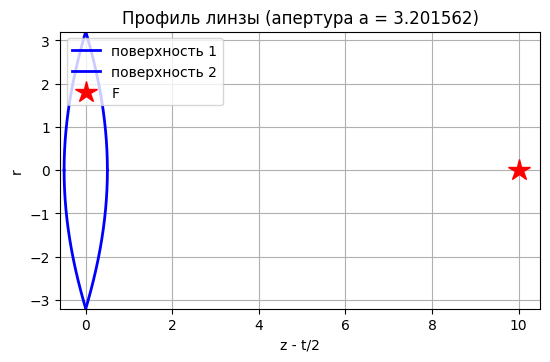

In [5]:
import matplotlib.pyplot as plt

rr = np.linspace(0, ap, 400)
z1 = z_sol(rr); z2 = t - z_sol(rr)

plt.figure(figsize=(6.2, 6))
plt.plot(z1 - t/2,  rr, 'b', lw=2, label='поверхность 1')
plt.plot(z2 - t/2,  rr, 'b', lw=2, label='поверхность 2')
plt.plot(z1 - t/2, -rr, 'b', lw=2)
plt.plot(z2 - t/2, -rr, 'b', lw=2)
plt.plot([zF - t/2], [0], 'r*', ms=16, label='F')
plt.xlabel('z - t/2'); plt.ylabel('r')
plt.xlim(-0.6, f + 0.5); plt.ylim(-ap, ap)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True); plt.legend(loc='upper left')
plt.title('Профиль линзы (апертура a = %.6f)' % ap)
plt.show()


## 7. Проверка: независимая трассировка лучей

Поверхность проверяем **независимым** способом: лучи трассируются по векторному закону Снелла на обеих поверхностях (без использования уравнения Ферма и замыкающего уравнения). Для идеальной линзы:

* фокус каждого луча совпадает с $F$ ($z_f=z_F$);
* оптическая длина постоянна: $\mathrm{OPL}=\mathrm{OPL}_0$.


In [6]:
def refract(d, normal, eta):
    cos_i = -np.dot(normal, d)
    k = 1.0 - eta*eta*(1.0 - cos_i*cos_i)
    if k < 0: return None
    cos_t = np.sqrt(k)
    tvec = eta*d + (eta*cos_i - cos_t)*normal
    return tvec/np.linalg.norm(tvec)

def trace_full(r1):
    z1 = float(z_sol(r1)); dz1 = float(dz_sol(r1))
    nrm1 = np.array([dz1, -1.0]); nrm1 /= np.linalg.norm(nrm1)
    d1 = refract(np.array([0.0, 1.0]), nrm1, 1.0/n)
    dr_dz = d1[0]/d1[1]
    def f2(r2):
        return z1 + (r2 - r1)/dr_dz - (t - z_sol(r2))
    r2 = brentq(f2, 0.0, r1, xtol=1e-13, rtol=1e-13)
    z2 = t - z_sol(r2)
    L_int = np.hypot(r2 - r1, z2 - z1); L_exit = np.hypot(r2, zF - z2)
    OPL = z1 + n*L_int + L_exit
    dz2 = -dz_sol(r2); nrm2 = np.array([dz2, -1.0]); nrm2 /= np.linalg.norm(nrm2)
    d2 = refract(d1, nrm2, n)
    zfoc = z2 - d2[1]*r2/d2[0]
    return zfoc, r2, OPL

rtr = np.linspace(ap/50, ap*0.99, 300)
zfs = np.array([trace_full(x)[0] for x in rtr])
opls = np.array([trace_full(x)[2] for x in rtr])
print("max|z_f - zF|     =", np.max(np.abs(zfs - zF)))
print("max|OPL - OPL0|    =", np.max(np.abs(opls - OPL0)))


max|z_f - zF|     = 2.12704872382119e-07
max|OPL - OPL0|    = 5.4214410738495644e-12


## 8. Итоговая формула поверхности

Математический профиль ($z_{\rm lens}(0)=0$) — чётное разложение до $r^{18}$:

$$
\boxed{\;
\begin{aligned}
z(r)=\;&5.170850194\times10^{-2}r^2
-3.069862096\times10^{-4}r^4\\
&+1.932778274\times10^{-6}r^6
+2.689897537\times10^{-8}r^8\\
&-1.507039271\times10^{-9}r^{10}
+2.831055327\times10^{-11}r^{12}\\
&+2.560362512\times10^{-13}r^{14}
-3.403878405\times10^{-14}r^{16}\\
&+8.472651009\times10^{-16}r^{18}.
\end{aligned}
\;}
$$

Для сайта используется смещённая версия $z_{\rm site}(r)=z_0+z(r)$ с $z_0=-0.5$. Однострочная формула, удобная для сайта:


In [7]:
def fmt(c):
    s = '%.9e' % abs(c); mant, exp = s.split('e')
    return '%se%03d' % (mant, int(exp))

terms = []
for k in (2, 4, 6, 8, 10, 12, 14, 16, 18):
    c = float(T[k]); sign = '+' if c >= 0 else '-'
    terms.append('%s%s*r^%d' % (sign, fmt(c), k))

print("z0" + ''.join(terms))


z0+5.170850194e-02*r^2-3.069862096e-04*r^4+1.932778274e-06*r^6+2.689897537e-08*r^8-1.507039271e-09*r^10+2.831055327e-11*r^12+2.560362512e-13*r^14-3.403878405e-14*r^16+8.472651009e-16*r^18


## Итог

* **Формулы.** Внутренний наклон луча $q(p)=-\dfrac{p(A-1)}{A+p^2}$ (из векторного Снелла) и условие Ферма $\mathrm{OPL}=\mathrm{OPL}_0$ вместе с симметрией $z_2=t-z_1$ дают запаздывающее функционально-дифференциальное уравнение $R(r,z,z')=0$ для поверхности.
* **Численное решение.** Интегрирование наружу от оси: ряд вблизи оси + неявный Ньютон (невязка + трапеция). Апертура $a\approx3.2015621187$ для $n=1.5$, $t=1$, $f=10$.
* **Проверка.** Независимая трассировка лучей: $\max|\mathrm{OPL}-\mathrm{OPL}_0|\approx5\!\cdot\!10^{-12}$, фокусная ошибка $\approx2\!\cdot\!10^{-7}$ — линза свободна от сферической аберрации.
* **Формула для сайта** — готовое чётное выражение до $r^{18}$ с координатным сдвигом $z_0=-0.5$.

## Источники
* [1] González-Acuña R. G. General formula for bi-aspheric singlet lens design free of spherical aberration // Applied Optics. — 2018. — Vol. 57, No. 31. — P. 9341–9345. — DOI:10.1364/AO.57.009341. — https://www.researchgate.net/profile/Rafael-G-Gonzalez-Acuna/2
